# 11 · 核销总量预测

> O2O 优惠券个性化投放项目 —— 第 11 步

---

## 本节目标与交付物

前 10 步的主线是**逐行排序**（预测某条发券记录会不会被核销，按概率排序）。
本节换一个目标：**7 月发出去的券，总共会核销多少张？**

| 项 | 内容 |
|---|---|
| **输入** | 7 月 100,669 条发券记录（**无 label**） |
| **交付物** | ① 7 月逐行预测表（含 `pred_prob` 与 `label`）　② 核销总量 + 误差区间 |
| **验收标准** | 跨段（滚动）总量误差，而非 AUC |

> ⚠️ 7 月的 `date` 列**全为空**（原始数据就只有发券信息），所以 7 月的 label
> **只能由模型生成**，不可能有真实值可对照。本节用滚动验证来估计误差。

## 与前 10 步的关系

本节**推翻**了第 09/10 步选出的建模方式，但保留其过程。原因见第 1~4 节：
那套 19 特征模型在**总量口径**下误差高达 +210%。这不是前十步做错了，
而是**目标不同，正确的模型就不同**——排序能力 ≠ 总量准确。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
import xgboost as xgb

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.unicode.east_asian_width', True)

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['savefig.bbox'] = 'tight'

ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / '.git').exists():
        ROOT = cand
        break

OUT_DIR = ROOT / 'data_out'
FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'

C_MAIN, C_ALT, C_WARN, C_GREY = '#2F6F9F', '#E08A3C', '#C0504D', '#8C8C8C'

## 1. 目标转变：从排序到总量

两者对模型的要求**完全不同**：

| | 排序（前 10 步） | 总量（本节） |
|---|---|---|
| 关心 | 谁排在前面 | **Σ预测概率** 是否等于 Σ实际核销 |
| 决定指标 | AUC（只管次序，不管标度） | **总量误差 / ECE**（只管标度） |
| 类别权重 `scale_pos_weight` | 有帮助 | **有害**——它把概率整体推高 |

一个 AUC 0.62 的模型可以同时把总量算错 200%——因为 AUC 对概率做任何
单调变换都不变，而总量对概率的**绝对大小**极其敏感。

In [2]:
df_train = pd.read_csv(OUT_DIR / 'clean_train.csv', parse_dates=['date_received', 'date'])
df_test = pd.read_csv(OUT_DIR / 'clean_test.csv', parse_dates=['date_received', 'date'])

print(f'1-6 月（有 label）: {len(df_train):,} 行')
print(f'7 月（无 label）  : {len(df_test):,} 行')
print()
print('各月核销率：')
g = df_train.groupby('receive_month').agg(发券=('class', 'size'), 核销=('class', 'sum'))
g['核销率%'] = (g['核销'] / g['发券'] * 100).round(2)
print(g.to_string())

1-6 月（有 label）: 947,279 行
7 月（无 label）  : 100,669 行

各月核销率：
                 发券   核销  核销率%
receive_month                        
1.0            339266   8592     2.53
2.0            118699   4815     4.06
3.0             93010  13874    14.92
4.0            126168   5233     4.15
5.0            188325  18828    10.00
6.0             81811   5718     6.99


### 1.1 第一个坏消息：月度核销率剧烈震荡

核销率在 **2.53% ~ 14.92%** 之间波动（6 倍差距），且**没有趋势**。
这一点必须先说清楚，因为它决定了误差区间的下限——**月度水平的漂移
是任何模型都无法消除的**，只能如实报告。

In [3]:
_month = g['核销率%'].values
print(f'月度核销率：均值 {_month.mean():.2f}%  标准差 {_month.std():.2f}%  '
      f'极差 {_month.max() - _month.min():.2f} 个百分点')
print(f'月度核销数：均值 {g["核销"].mean():,.0f}  标准差 {g["核销"].std():,.0f}  '
      f'变异系数 {g["核销"].std() / g["核销"].mean():.3f}')
print()
print('核销高度集中在少数券上（Top20 券占该月核销的比例）：')
for m in range(1, 7):
    s = df_train[(df_train['receive_month'] == m) & (df_train['class'] == 1)]
    top20 = s['coupon_id'].value_counts().head(20).sum()
    print(f'  {m}月: 核销 {len(s):>6,}  Top20券贡献 {top20 / len(s) * 100:>5.1f}%  '
          f'唯一券 {s["coupon_id"].nunique():>5,} 张')

月度核销率：均值 7.11%  标准差 4.25%  极差 12.39 个百分点
月度核销数：均值 9,510  标准差 5,682  变异系数 0.597

核销高度集中在少数券上（Top20 券占该月核销的比例）：
  1月: 核销  8,592  Top20券贡献  75.7%  唯一券   406 张
  2月: 核销  4,815  Top20券贡献  77.9%  唯一券   334 张
  3月: 核销 13,874  Top20券贡献  60.3%  唯一券   799 张
  4月: 核销  5,233  Top20券贡献  31.8%  唯一券 1,332 张
  5月: 核销 18,828  Top20券贡献  25.2%  唯一券 3,107 张
  6月: 核销  5,718  Top20券贡献  38.9%  唯一券 1,256 张


## 2. 滚动验证框架

7 月没有 label，所以**必须用历史模拟**来估计误差：

```
轮次 1: 训练 1-3 月  →  eval 5 月
轮次 2: 训练 1-4 月  →  eval 6 月
轮次 3: 训练 1-5 月  →  eval 6 月
```

每一轮只做一件事：**用截止月之前的数据，预测下一个月（或隔一月）的核销总量**，
再和实际比。三轮的误差分布，就是 7 月误差的估计。

In [4]:
SCENARIOS = [(3, 5), (4, 6), (5, 6)]

def total_error(y, p):
    return (np.asarray(p).sum() - np.asarray(y).sum()) / np.asarray(y).sum() * 100


def ece(y, p, bins=10):
    """期望校准误差：完全校准 => ECE=0 => 总量误差=0"""
    y, p = np.asarray(y), np.asarray(p)
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, bins - 1)
    return sum(m.mean() * abs(y[m].mean() - p[m].mean())
               for b in range(bins) if (m := idx == b).sum() > 0)


def score(tag, y, p):
    return {'方法': tag, '预测总量': round(np.sum(p)), '实际总量': int(np.sum(y)),
            '总量误差%': round(total_error(y, p), 2),
            'AUC': round(roc_auc_score(y, p), 4),
            'Brier': round(brier_score_loss(y, p), 4),
            'ECE': round(ece(y, p), 4)}

print('滚动场景：', SCENARIOS)

滚动场景： [(3, 5), (4, 6), (5, 6)]


## 3. 对照：19 特征模型在总量口径下的表现

先把第 08 节的特征工程原样搬过来（保证无泄漏：画像只来自训练段），
用第 09 节的超参训练，看它在**总量**口径下是什么水平。

In [5]:
FEATURES = [
    'discount_rate', 'distance',
    'received_weekday', 'received_is_weekend', 'received_day',
    'user_use_coupon_times', 'user_consume_times', 'user_use_coupon_rate',
    'user_receive_unused', 'user_mean_interval',
    'merchant_launch_coupon_used_count', 'merchant_launch_coupon_used_rate',
    'merchant_launch_coupon_count', 'merchant_receive_unused', 'merchant_mean_interval',
    'coupon_receive_times', 'coupon_consume_times', 'coupon_fifteen_used', 'coupon_used_rate',
]
AGG_COLS = [c for c in FEATURES if c not in
            ('discount_rate', 'distance', 'received_weekday', 'received_is_weekend', 'received_day')]

XGB_PARAMS = dict(max_depth=4, learning_rate=0.05, n_estimators=100,
                  subsample=0.8, colsample_bytree=0.8, random_state=42,
                  n_jobs=-1, eval_metric='auc')


def build_features(train_seg, targets):
    """在 train_seg 上算画像，拼接到 targets（与第 08 节逻辑逐列一致）。

    关键：所有 groupby 只在 train_seg 上执行 -> 无泄漏。
    每个滚动轮次都要重算，不能复用全量画像。
    """
    s = train_seg
    s = s.assign(
        _use_coupon=(s[['date_received', 'date']].count(axis=1) == 2).astype(int),
        _consumed=s['date'].notna().astype(int),
        _received_unused=(s['coupon_id'].notna() & s['date'].isna()).astype(int))

    g = s.groupby('user_id')
    du = pd.DataFrame({
        'user_use_coupon_times': g['_use_coupon'].sum(),
        'user_consume_times': g['_consumed'].sum(),
        'user_receive_unused': g['_received_unused'].sum(),
        'user_mean_interval': g['gap'].mean()}).reset_index()
    du['user_use_coupon_rate'] = (du['user_use_coupon_times'] / du['user_consume_times']).fillna(0)
    du['user_mean_interval'] = du['user_mean_interval'].fillna(du['user_mean_interval'].max() + 1)

    gm = s.groupby('merchant_id')
    dm = pd.DataFrame({
        'merchant_launch_coupon_used_count': gm['_use_coupon'].sum(),
        'merchant_consume_times': gm['_consumed'].sum(),
        'merchant_launch_coupon_count': gm['coupon_id'].count(),
        'merchant_receive_unused': gm['_received_unused'].sum(),
        'merchant_mean_interval': gm['gap'].mean()}).reset_index()
    dm['merchant_launch_coupon_used_rate'] = (
        dm['merchant_launch_coupon_used_count'] / dm['merchant_consume_times']).fillna(0)
    dm['merchant_mean_interval'] = dm['merchant_mean_interval'].fillna(dm['merchant_mean_interval'].max() + 1)

    c15 = s[s['gap'] <= 15]
    gc, g15 = s.groupby('coupon_id'), c15.groupby('coupon_id')
    dc = pd.DataFrame({
        'coupon_receive_times': gc['coupon_id'].count(),
        'coupon_consume_times': gc['_consumed'].sum(),
        'coupon_fifteen_used': g15.size()}).reset_index()
    dc['coupon_fifteen_used'] = dc['coupon_fifteen_used'].fillna(0)
    dc['coupon_used_rate'] = (dc['coupon_fifteen_used'] / dc['coupon_consume_times']).fillna(0)

    med_dr, med_dist = train_seg['discount_rate'].median(), train_seg['distance'].median()
    out = {}
    for name, seg in targets.items():
        m = seg.merge(du, on='user_id', how='left').merge(dm, on='merchant_id', how='left')
        m = m.merge(dc, on='coupon_id', how='left')
        dr = pd.to_datetime(m['date_received'])
        m['received_weekday'] = dr.dt.weekday
        m['received_is_weekend'] = (dr.dt.weekday >= 5).astype(int)
        m['received_day'] = dr.dt.day
        m[AGG_COLS] = m[AGG_COLS].fillna(0)
        m['discount_rate'] = m['discount_rate'].fillna(med_dr)
        m['distance'] = m['distance'].fillna(med_dist)
        out[name] = m
    return out


rows = []
importance_rows = []
cache = {}   # 缓存 (cut, ev_m) -> (y, p19)，供第 5 节复用

In [6]:
for cut, ev_m in [(3, 5), (4, 6), (5, 6)]:
    tr = df_train[df_train['receive_month'] <= cut]
    ev = df_train[df_train['receive_month'] == ev_m]
    segs = build_features(tr, {'__train__': tr, 'ev': ev})
    t, e = segs['__train__'], segs['ev']
    spw = (t['class'] == 0).sum() / max((t['class'] == 1).sum(), 1)

    m19 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)
    m19.fit(t[FEATURES], t['class'])
    p19 = m19.predict_proba(e[FEATURES])[:, 1]
    cache[(cut, ev_m)] = (e['class'].values, p19)

    rows.append(score(f'轮 train<={cut}→eval{ev_m} · 19特征XGB', e['class'].values, p19))
    print(f'  轮 train<={cut} → eval={ev_m}: 19特征XGB 预测 {p19.sum():,.0f} / '
          f'实际 {e["class"].sum():,}  ({total_error(e["class"].values, p19):+.1f}%)  '
          f'AUC={roc_auc_score(e["class"], p19):.4f}', flush=True)

    imp = pd.Series(m19.feature_importances_, index=FEATURES).sort_values(ascending=False)
    importance_rows.append({'轮次': f'train<={cut}', **imp.head(8).round(4).to_dict(),
                            'distance排名': list(imp.index).index('distance') + 1})

baseline_xgb = pd.DataFrame(rows)
print()
print(baseline_xgb.to_string(index=False))

  轮 train<=3 → eval=5: 19特征XGB 预测 88,137 / 实际 18,828  (+368.1%)  AUC=0.4950


  轮 train<=4 → eval=6: 19特征XGB 预测 23,814 / 实际 5,718  (+316.5%)  AUC=0.5062


  轮 train<=5 → eval=6: 19特征XGB 预测 17,745 / 实际 5,718  (+210.3%)  AUC=0.6227



                         方法  预测总量  实际总量  总量误差%    AUC  Brier    ECE
轮 train<=3→eval5 · 19特征XGB     88137     18828     368.11 0.4950 0.3202 0.4247
轮 train<=4→eval6 · 19特征XGB     23814      5718     316.48 0.5062 0.1797 0.2679
轮 train<=5→eval6 · 19特征XGB     17745      5718     210.33 0.6227 0.1554 0.1888


### 3.1 结论：19 特征模型不能用于总量

误差在 **+200% 以上**。看特征重要性就明白了：

In [7]:
imp_df = pd.DataFrame(importance_rows)
print('各轮 19 特征模型的 Top8 重要性：')
print(imp_df.to_string(index=False))
imp_df.to_csv(TAB_DIR / '11_importance_diagnosis.csv', index=False, encoding='utf-8-sig')

各轮 19 特征模型的 Top8 重要性：
    轮次  user_mean_interval  user_consume_times  user_use_coupon_times  user_receive_unused  distance  coupon_used_rate  coupon_receive_times  coupon_fifteen_used  distance排名  merchant_receive_unused
train<=3              0.6480              0.1141                 0.0718               0.0334    0.0197            0.0170                0.0146               0.0137             5                      NaN
train<=4              0.6688              0.0970                 0.0760               0.0287    0.0193            0.0173                0.0136                  NaN             5                   0.0160
train<=5              0.6671              0.1004                 0.0655               0.0262    0.0184            0.0248                0.0158                  NaN             7                   0.0203


`user_mean_interval`（用户历史核销间隔）**独占约 2/3 的重要性**，
但它在第 10 节已被证明与标签几乎无关（相关系数 −0.08）。
它是**连续值、取值分散**，分裂增益天然偏向这类特征——
于是模型把分裂预算几乎全花在一个噪声特征上，
而把概率整体推向高位（`scale_pos_weight` 又放大了这一点）。

真正有信号的 `distance` 排在第 5~7 位，重要性不到 2%。

## 4. 诊断：09 节的 AUC 0.6227 从哪来

把训练段的截止月往上推，看 AUC 怎么变：

In [8]:
auc_rows = []
for cut in [1, 2, 3, 4, 5]:
    tr = df_train[df_train['receive_month'] <= cut]
    ev = df_train[df_train['receive_month'] == 6]
    if len(tr) < 1000:
        continue
    segs = build_features(tr, {'__train__': tr, 'ev': ev})
    t, e = segs['__train__'], segs['ev']
    spw = (t['class'] == 0).sum() / max((t['class'] == 1).sum(), 1)
    m = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw)
    m.fit(t[FEATURES], t['class'])
    p = m.predict_proba(e[FEATURES])[:, 1]
    seen = set(tr['coupon_id'])
    auc_rows.append({'训练段': f'1-{cut}月', '训练行数': f'{len(t):,}',
                     '训练段核销率%': round(t['class'].mean() * 100, 2),
                     '6月AUC': round(roc_auc_score(e['class'], p), 4),
                     '6月行中老券占比%': round(e['coupon_id'].isin(seen).mean() * 100, 1)})
    print(f'  train<= {cut}月 -> 6月 AUC = {auc_rows[-1]["6月AUC"]:.4f}  '
          f'(6月老券按行占比 {auc_rows[-1]["6月行中老券占比%"]}%)', flush=True)

auc_df = pd.DataFrame(auc_rows)
auc_df.to_csv(TAB_DIR / '11_auc_sources.csv', index=False, encoding='utf-8-sig')
print()
print(auc_df.to_string(index=False))

  train<= 1月 -> 6月 AUC = 0.5931  (6月老券按行占比 0.8%)


  train<= 2月 -> 6月 AUC = 0.4948  (6月老券按行占比 0.8%)


  train<= 3月 -> 6月 AUC = 0.5084  (6月老券按行占比 1.5%)


  train<= 4月 -> 6月 AUC = 0.5062  (6月老券按行占比 6.8%)


  train<= 5月 -> 6月 AUC = 0.6227  (6月老券按行占比 31.2%)



训练段 训练行数  训练段核销率%  6月AUC  6月行中老券占比%
 1-1月  339,266           2.53  0.5931               0.8
 1-2月  457,965           2.93  0.4948               0.8
 1-3月  550,975           4.95  0.5084               1.5
 1-4月  677,143           4.80  0.5062               6.8
 1-5月  865,468           5.93  0.6227              31.2


这张表最重要的信息不是「哪一行最高」，而是**它有多不稳定**：

- 训练段只差一个月（1-1月 → 1-2月），AUC 就从 **0.5931 掉到 0.4948**
- 五行的 AUC 在 **0.49 ~ 0.62** 之间无规律跳动，没有趋势
- 唯一达到 0.62 的是最后一轮，而它恰好是**老券按行占比最高**（31.2%）的一轮

也就是说：**这个 AUC 的高低主要取决于「评估月里的券有多大比例在训练段出现过」，
而不是模型学到了什么可迁移的规律**。前几轮老券占比不足 2% 时，AUC 几乎就是随机。

> 这对本节的启示：**任何依赖「券的历史」的特征，在 7 月都不可靠**——
> 7 月有 **84.1%** 的发券记录落在训练段没见过的券上（第 8 节实测；
> 第 07 节按 1-5 月口径算得 88.7%）。

## 5. 找到稳定信号：`distance`

换个思路。既然依赖历史的特征不可靠，就找**不依赖历史**的特征：
`distance`（用户到商户的距离）和 `discount_rate` 都是发券时就已知的事件属性。

先看它们在**每个月**的表现是否稳定：

In [9]:
df_train['dbin'] = pd.cut(df_train['distance'], [-1, 0.5, 1.5, 2.5, 4.5, 7.5, 100])
df_train['drbin'] = pd.cut(df_train['discount_rate'], [0, 0.6, 0.8, 0.9, 0.95, 0.99, 1.01])

print('各月 × 距离档 的核销率(%)：')
pt_dist = df_train.pivot_table(index='dbin', columns='receive_month', values='class',
                               aggfunc='mean', observed=True) * 100
print(pt_dist.round(2).to_string())
print()
print('各月 × 折扣率档 的核销率(%)：')
pt_dr = df_train.pivot_table(index='drbin', columns='receive_month', values='class',
                             aggfunc='mean', observed=True) * 100
print(pt_dr.round(2).to_string())

各月 × 距离档 的核销率(%)：
receive_month   1.0   2.0    3.0   4.0    5.0   6.0
dbin                                               
(-1.0, 0.5]    7.88  9.45  19.44  7.84  13.77  9.56
(0.5, 1.5]     2.46  3.18  12.27  3.13   7.41  4.56
(1.5, 2.5]     1.47  2.12  10.04  2.60   6.53  3.52
(2.5, 4.5]     0.87  1.47   7.08  2.10   5.89  4.50
(4.5, 7.5]     0.62  1.07   6.53  1.75   4.83  4.00
(7.5, 100.0]   0.25  0.50   6.01  1.58   4.92  5.02

各月 × 折扣率档 的核销率(%)：
receive_month   1.0   2.0    3.0    4.0    5.0    6.0
drbin                                                
(0.0, 0.6]     5.83  8.62  33.10  27.49   3.94   4.65
(0.6, 0.8]     1.31  2.30  23.20   8.47  10.22   6.08
(0.8, 0.9]     2.43  4.14  10.28   2.72   9.31   5.49
(0.9, 0.95]    6.56  6.12   9.37  11.50  13.52  14.30
(0.95, 0.99]   8.89  7.08   7.11  11.16  11.61  13.43


| 特征 | 跨月表现 |
|---|---|
| **`distance`** | **「近高远低」的次序每个月都成立**；前 4 个月严格单调递减，5-6 月的远距离档有轻微反弹（约 4%~5%） |
| `discount_rate` | **方向会反转**（月 3/4 是低折扣率核销率高，月 5/6 反过来）——**不可用** |

`distance` 的单调性在两个月里不是严格的，但**「近 >> 远」这个次序从未失效**：
`distance=0` 档的核销率始终是远距离档的 2~29 倍。这正是 isotonic 回归要利用的结构
——它会把那点反弹平滑掉，强制出一条单调曲线。

而且它还有个决定性优势：**新券、新用户同样有 `distance`**——不受冷启动影响。

In [10]:
single_rows = []
for cut, ev_m in [(3, 5), (4, 6), (5, 6)]:
    tr = df_train[df_train['receive_month'] <= cut]
    ev = df_train[df_train['receive_month'] == ev_m]
    y, p19 = cache[(cut, ev_m)]          # 复用第 3 节已训练的 19 特征模型
    spw = (tr['class'] == 0).sum() / max((tr['class'] == 1).sum(), 1)

    # distance 是原始列，不需要画像 -> 直接在原始表上训练
    m1 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw).fit(tr[['distance']], tr['class'])
    p1 = m1.predict_proba(ev[['distance']])[:, 1]

    single_rows.append({'轮次': f'train<={cut}→eval{ev_m}',
                        '19特征 AUC': round(roc_auc_score(y, p19), 4),
                        'distance单特征 AUC': round(roc_auc_score(y, p1), 4)})
    print(f'  train<={cut} → eval={ev_m}:  19特征 AUC={single_rows[-1]["19特征 AUC"]:.4f}   '
          f'distance 单特征 AUC={single_rows[-1]["distance单特征 AUC"]:.4f}', flush=True)

single_df = pd.DataFrame(single_rows)
single_df.to_csv(TAB_DIR / '11_distance_vs_full.csv', index=False, encoding='utf-8-sig')
print()
print(single_df.to_string(index=False))

  train<=3 → eval=5:  19特征 AUC=0.4950   distance 单特征 AUC=0.6139


  train<=4 → eval=6:  19特征 AUC=0.5062   distance 单特征 AUC=0.5981


  train<=5 → eval=6:  19特征 AUC=0.6227   distance 单特征 AUC=0.5980



          轮次  19特征 AUC  distance单特征 AUC
train<=3→eval5      0.4950              0.6139
train<=4→eval6      0.5062              0.5981
train<=5→eval6      0.6227              0.5980


**在 3 轮中的 2 轮，`distance` 单特征 AUC 高于 19 特征模型**
（0.6139 vs 0.4950、0.5981 vs 0.5062）；第 3 轮 19 特征略高（0.6227 vs 0.5980）。

单看 AUC，只能说两者接近。但**决定性证据在总量口径**：同一个 19 特征模型
总量误差 **+298%**，而 distance 曲线只有 **13%**。

这不是说特征工程没用，而是说：**当 18 个噪声特征稀释了唯一有效的信号时，
加特征就是减分**。第 08 节的画像特征既没提供信息，又破坏了概率标度
（`user_mean_interval` 把预测概率整体推高）。

## 6. 方法定稿：distance 单调曲线

既然核销率**随距离递减**（近似单调），最自然的方法不是树模型，而是直接拟合
一条**单调递减曲线**：`isotonic regression`（保序回归）。

它比手工分箱更平滑、更少过拟合，且天然满足单调约束。

同时验证一个常见想法：**用近期数据是否比用全历史好？**

In [11]:
curve_rows = []
for cut, ev_m in [(3, 5), (4, 6), (5, 6)]:
    tr = df_train[df_train['receive_month'] <= cut]
    ev = df_train[df_train['receive_month'] == ev_m]
    y = ev['class'].values

    for cname, sub in [('全历史', tr),
                       ('最近3个月', tr[tr['receive_month'] >= cut - 2]),
                       ('最近2个月', tr[tr['receive_month'] >= cut - 1])]:
        if len(sub) < 1000:
            continue
        iso = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1, increasing=False)
        iso.fit(sub['distance'].values, sub['class'].values)
        p = iso.predict(ev['distance'].values)
        curve_rows.append({'轮次': f'train<={cut}→eval{ev_m}', '曲线窗口': cname,
                           '预测总量': round(p.sum()), '实际总量': int(y.sum()),
                           '总量误差%': round(total_error(y, p), 2),
                           'AUC': round(roc_auc_score(y, p), 4)})
        print(f'  train<={cut} → eval={ev_m} [{cname}]: 预测 {p.sum():,.0f} / 实际 {y.sum():,} '
              f'({total_error(y, p):+.2f}%)  AUC={roc_auc_score(y, p):.4f}', flush=True)

curve_df = pd.DataFrame(curve_rows)
curve_df.to_csv(TAB_DIR / '11_curve_window.csv', index=False, encoding='utf-8-sig')
print()
print('各窗口的跨轮平均绝对误差：')
print(curve_df.groupby('曲线窗口')['总量误差%'].apply(
    lambda s: round(s.abs().mean(), 2)).sort_values().to_string())

  train<=3 → eval=5 [全历史]: 预测 13,578 / 实际 18,828 (-27.88%)  AUC=0.6139


  train<=3 → eval=5 [最近3个月]: 预测 13,578 / 实际 18,828 (-27.88%)  AUC=0.6139


  train<=3 → eval=5 [最近2个月]: 预测 18,756 / 实际 18,828 (-0.38%)  AUC=0.6139


  train<=4 → eval=6 [全历史]: 预测 5,610 / 实际 5,718 (-1.88%)  AUC=0.5981


  train<=4 → eval=6 [最近3个月]: 预测 6,880 / 实际 5,718 (+20.32%)  AUC=0.5980


  train<=4 → eval=6 [最近2个月]: 预测 7,872 / 实际 5,718 (+37.67%)  AUC=0.5980


  train<=5 → eval=6 [全历史]: 预测 6,241 / 实际 5,718 (+9.15%)  AUC=0.5980


  train<=5 → eval=6 [最近3个月]: 预测 8,006 / 实际 5,718 (+40.01%)  AUC=0.5980


  train<=5 → eval=6 [最近2个月]: 预测 6,760 / 实际 5,718 (+18.22%)  AUC=0.5981



各窗口的跨轮平均绝对误差：
曲线窗口
全历史       12.97
最近2个月    18.76
最近3个月    29.40


**全历史最好**（平均绝对值 12.97%），近期窗口反而更差（最近 3 月 29.40%、
最近 2 月 18.76%）。原因是距离-核销率曲线本身不含趋势，用更多月份平均
能降低噪声；只用近 1~2 个月，反而把单月波动当成了信号。

> 单轮有例外：`train≤3→5月` 那一轮「最近 2 月」更好（−0.38% vs −27.88%）。
> 但那是不可复现的偶然——三轮平均才是可靠判据。

## 7. 跨段验证：三种方法横评

现在把候选方法放在同一张表上比较。评估基准是**总量误差**（主）
与 ECE（诊断），AUC 只作参考列。

In [12]:
final_rows = []
for cut, ev_m in [(3, 5), (4, 6), (5, 6)]:
    tr = df_train[df_train['receive_month'] <= cut]
    ev = df_train[df_train['receive_month'] == ev_m]
    y = ev['class'].values
    tag = f'轮 train<={cut}→eval{ev_m}'

    # M0 基线：训练段整体核销率
    final_rows.append(score(f'{tag} · M0 基线(历史核销率)',
                            y, np.full(len(y), tr['class'].mean())))

    # M1 19 特征 XGB
    segs = build_features(tr, {'__train__': tr, 'ev': ev})
    t, e = segs['__train__'], segs['ev']
    spw = (t['class'] == 0).sum() / max((t['class'] == 1).sum(), 1)
    m19 = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw).fit(t[FEATURES], t['class'])
    final_rows.append(score(f'{tag} · M1 19特征XGB', y,
                            m19.predict_proba(e[FEATURES])[:, 1]))

    # M2 最终方法：distance isotonic 曲线
    iso = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1, increasing=False)
    iso.fit(tr['distance'].values, tr['class'].values)
    final_rows.append(score(f'{tag} · M2 distance曲线', y, iso.predict(ev['distance'].values)))
    print(f'  {tag} 完成', flush=True)

final_df = pd.DataFrame(final_rows)
final_df['方法名'] = final_df['方法'].str.replace(r'^轮 train<=\d+→eval\d+ · ', '', regex=True)
final_df.to_csv(TAB_DIR / '11_method_comparison.csv', index=False, encoding='utf-8-sig')

print()
print(final_df.to_string(index=False))
print()
summary = final_df.groupby('方法名').agg(
    平均绝对误差=('总量误差%', lambda s: round(s.abs().mean(), 2)),
    最差误差=('总量误差%', lambda s: round(s.abs().max(), 2)),
    平均AUC=('AUC', 'mean'), 平均Brier=('Brier', 'mean'),
    平均ECE=('ECE', 'mean')).round(4).sort_values('平均绝对误差')
summary.to_csv(TAB_DIR / '11_method_summary.csv', encoding='utf-8-sig')
print('=== 跨轮汇总 ===')
print(summary.to_string())

  轮 train<=3→eval5 完成


  轮 train<=4→eval6 完成


  轮 train<=5→eval6 完成



                                   方法  预测总量  实际总量  总量误差%    AUC  Brier    ECE              方法名
轮 train<=3→eval5 · M0 基线(历史核销率)      9325     18828     -50.47 0.5000 0.0925 0.0505 M0 基线(历史核销率)
       轮 train<=3→eval5 · M1 19特征XGB     88137     18828     368.11 0.4950 0.3202 0.4247        M1 19特征XGB
    轮 train<=3→eval5 · M2 distance曲线     13578     18828     -27.88 0.6139 0.0893 0.0279     M2 distance曲线
轮 train<=4→eval6 · M0 基线(历史核销率)      3928      5718     -31.30 0.5000 0.0655 0.0219 M0 基线(历史核销率)
       轮 train<=4→eval6 · M1 19特征XGB     23814      5718     316.48 0.5062 0.1797 0.2679        M1 19特征XGB
    轮 train<=4→eval6 · M2 distance曲线      5610      5718      -1.88 0.5981 0.0647 0.0154     M2 distance曲线
轮 train<=5→eval6 · M0 基线(历史核销率)      4853      5718     -15.12 0.5000 0.0651 0.0106 M0 基线(历史核销率)
       轮 train<=5→eval6 · M1 19特征XGB     17745      5718     210.33 0.6227 0.1554 0.1888        M1 19特征XGB
    轮 train<=5→eval6 · M2 distance曲线      6241      5718       9.15 0.5980 0.0

### 7.1 结果解读

| 方法 | 平均绝对误差 | 说明 |
|---|---|---|
| **M2 distance 曲线** | **12.97%** | 最终采用 |
| M0 基线（历史核销率） | 32.30% | 不用模型的下限对照 |
| M1 19 特征 XGB | 298.31% | 不可用 |

最终方法相对基线把误差**降低了约 2.5 倍**，这是它值得被采用的理由。

但必须正视：**13% 只是历史三轮的平均，其中一轮（train≤3→5月）高达 −28%**。
那一轮的问题是 5 月整体核销率（10.00%）远高于训练段（4.95%）——
**月度水平漂移**，任何模型都修不掉。

## 8. 7 月分布检查

跨段误差能否外推到 7 月，取决于 7 月的结构是否与历史相似。

In [13]:
df_test['dbin'] = pd.cut(df_test['distance'], [-1, 0.5, 1.5, 2.5, 4.5, 7.5, 100])
a = df_train['dbin'].value_counts(normalize=True).sort_index() * 100
b = df_test['dbin'].value_counts(normalize=True).sort_index() * 100
dist_cmp = pd.DataFrame({'1-6月占比%': a.round(1), '7月占比%': b.round(1),
                         '7月行数': df_test['dbin'].value_counts().sort_index()})
dist_cmp['占比变化'] = (dist_cmp['7月占比%'] - dist_cmp['1-6月占比%']).round(1)
dist_cmp.to_csv(TAB_DIR / '11_july_distribution.csv', encoding='utf-8-sig')
print('7 月 vs 1-6 月的距离分布：')
print(dist_cmp.to_string())

7 月 vs 1-6 月的距离分布：
              1-6月占比%  7月占比%  7月行数  占比变化
dbin                                                 
(-1.0, 0.5]         36.8      43.3    43556       6.5
(0.5, 1.5]          15.2      18.2    18306       3.0
(1.5, 2.5]           8.6       9.4     9438       0.8
(2.5, 4.5]          10.1       9.8     9839      -0.3
(4.5, 7.5]           8.0       6.7     6767      -1.3
(7.5, 100.0]        21.4      12.7    12763      -8.7


In [14]:
print('7 月结构概览：')
for name, d in [('6月', df_train[df_train['receive_month'] == 6]), ('7月', df_test)]:
    print(f'  {name}: 发券 {len(d):>7,} 行  唯一券 {d["coupon_id"].nunique():>5,}  '
          f'唯一用户 {d["user_id"].nunique():>6,}  平均距离 {d["distance"].mean():.2f}')

seen_coupons = set(df_train['coupon_id'])
cov_rows = df_test['coupon_id'].isin(seen_coupons).mean() * 100
cov_uq = df_test['coupon_id'].drop_duplicates().isin(seen_coupons).mean() * 100
print(f'  7月券在 1-6 月出现过：按行 {cov_rows:.1f}%   按唯一券 {cov_uq:.1f}%')

7 月结构概览：
  6月: 发券  81,811 行  唯一券 3,142  唯一用户 68,818  平均距离 1.79
  7月: 发券 100,669 行  唯一券 1,965  唯一用户 68,258  平均距离 2.32
  7月券在 1-6 月出现过：按行 15.9%   按唯一券 52.8%


**7 月的分布在两个方向上都更有利**：

1. `distance=0` 档占比从 36.8% 升到 **43.3%**——而这一档恰是**跨月最稳定**的
   （各月 7.84%~19.44%，波动约 2.5 倍；而远距离档波动可达 20 倍）
2. 波动最大的远距离档（>7.5）占比从 21.4% 降到 **12.7%**

也就是说，**7 月的预测风险结构比第 3 轮（5 月）更好**。

## 9. 最终交付：7 月逐行预测 + 总量

交付物有两件：

1. **7 月逐行预测表**：每条发券记录一行，含 `pred_prob`（预测核销概率）
   和 `label`（0/1）
2. **总量**：`label.sum()`，即预计核销张数

### label 怎么定

`pred_prob` 是一个 0~1 的概率，直接四舍五入（阈值 0.5）会**几乎全判为 0**，
因为校准后 7 月的平均概率只有约 7%。正确做法是**按总量反推阈值**：

```
K = round(Σ pred_prob)        # 期望核销张数
按 pred_prob 降序取前 K 行 -> label=1，其余 0
```

这样 `Σ label = K = Σ pred_prob`，**两种口径的总量完全一致**，
同时给出了"具体是哪 K 张券"。

In [15]:
iso_final = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1, increasing=False)
iso_final.fit(df_train['distance'].values, df_train['class'].values)

p_july = iso_final.predict(df_test['distance'].values)
K = int(round(p_july.sum()))

order = np.argsort(-p_july, kind='stable')
label_july = np.zeros(len(p_july), dtype=int)
label_july[order[:K]] = 1

july = pd.DataFrame({
    'user_id': df_test['user_id'],
    'merchant_id': df_test['merchant_id'],
    'coupon_id': df_test['coupon_id'],
    'date_received': df_test['date_received'].dt.strftime('%Y-%m-%d'),
    'distance': df_test['distance'],
    'discount_rate': df_test['discount_rate'],
    'pred_prob': np.round(p_july, 6),
    'label': label_july,
})
july.to_csv(OUT_DIR / 'july_predictions.csv', index=False)

print(f'7 月发券行数      : {len(july):,}')
print(f'预测核销总量 (K)  : {K:,}')
print(f'隐含核销率        : {p_july.mean() * 100:.2f}%')
print(f'Σpred_prob        : {p_july.sum():,.2f}   Σlabel = {label_july.sum():,}  (一致)')
print()
print('预测概率分布：')
print(pd.Series(p_july).describe().round(4).to_string())
print()
print('已导出: data_out/july_predictions.csv')

7 月发券行数      : 100,669
预测核销总量 (K)  : 6,858
隐含核销率        : 6.81%
Σpred_prob        : 6,858.37   Σlabel = 6,858  (一致)

预测概率分布：
count    100669.0000
mean          0.0681
std           0.0429
min           0.0121
25%           0.0271
50%           0.0501
75%           0.1157
max           0.1157

已导出: data_out/july_predictions.csv


In [16]:
print('7 月各距离档的预测贡献：')
rate_curve = df_train.groupby('dbin', observed=True)['class'].mean()
te2 = df_test.assign(p=p_july)
contrib = te2.groupby('dbin', observed=True).agg(行数=('p', 'size'), 预测核销=('p', 'sum'))
contrib['曲线核销率%'] = (rate_curve.reindex(contrib.index).to_numpy() * 100).round(2)
contrib['贡献%'] = (contrib['预测核销'] / contrib['预测核销'].sum() * 100).round(1)
contrib.to_csv(TAB_DIR / '11_july_contribution.csv', encoding='utf-8-sig')
print(contrib.round(0).to_string())

7 月各距离档的预测贡献：
               行数  预测核销  曲线核销率%  贡献%
dbin                                             
(-1.0, 0.5]   43556    5039.0         12.0   74.0
(0.5, 1.5]    18306     918.0          5.0   13.0
(1.5, 2.5]     9438     333.0          4.0    5.0
(2.5, 4.5]     9839     261.0          3.0    4.0
(4.5, 7.5]     6767     138.0          2.0    2.0
(7.5, 100.0]  12763     170.0          1.0    2.0


### 9.1 误差区间

三轮滚动验证的总量误差是 −27.88% / −1.88% / +9.15%，平均绝对值 12.97%。
取最保守的口径作为区间：

In [17]:
errs = final_df[final_df['方法名'] == 'M2 distance曲线']['总量误差%'].values
lo, hi = errs.min(), errs.max()
band = pd.DataFrame([
    {'口径': '点估计', '值': f'{K:,} 张', '说明': 'Σpred_prob 四舍五入'},
    {'口径': f'乐观（跨段最好一轮 {hi:+.1f}%）', '值': f'{round(K * (1 + hi / 100)):,} 张',
     '说明': '按最好一轮的外推'},
    {'口径': f'悲观（跨段最差一轮 {lo:+.1f}%）', '值': f'{round(K * (1 + lo / 100)):,} 张',
     '说明': '按最差一轮的外推'},
    {'口径': '历史月度核销数均值', '值': f'{df_train.groupby("receive_month")["class"].sum().mean():,.0f} 张',
     '说明': '不用模型的朴素对照'},
])
band.to_csv(TAB_DIR / '11_forecast_band.csv', index=False, encoding='utf-8-sig')
print(band.to_string(index=False))
print()
print('注：悲观口径来自 train<=3→5月 那一轮，原因是 5 月整体核销率(10.00%)远高于训练段(4.95%)，')
print('    属于月度水平漂移。7 月 distance 分布更集中于稳定的 0 档，实际风险应小于该悲观值。')

                       口径       值                说明
                     点估计 6,858 张 Σpred_prob 四舍五入
 乐观（跨段最好一轮 +9.2%） 7,486 张    按最好一轮的外推
悲观（跨段最差一轮 -27.9%） 4,946 张    按最差一轮的外推
         历史月度核销数均值 9,510 张  不用模型的朴素对照

注：悲观口径来自 train<=3→5月 那一轮，原因是 5 月整体核销率(10.00%)远高于训练段(4.95%)，
    属于月度水平漂移。7 月 distance 分布更集中于稳定的 0 档，实际风险应小于该悲观值。


## 10. 可视化

C:\Users\20176\AppData\Local\Temp\ipykernel_66920\2986742378.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(lbl, rotation=20, fontsize=8)


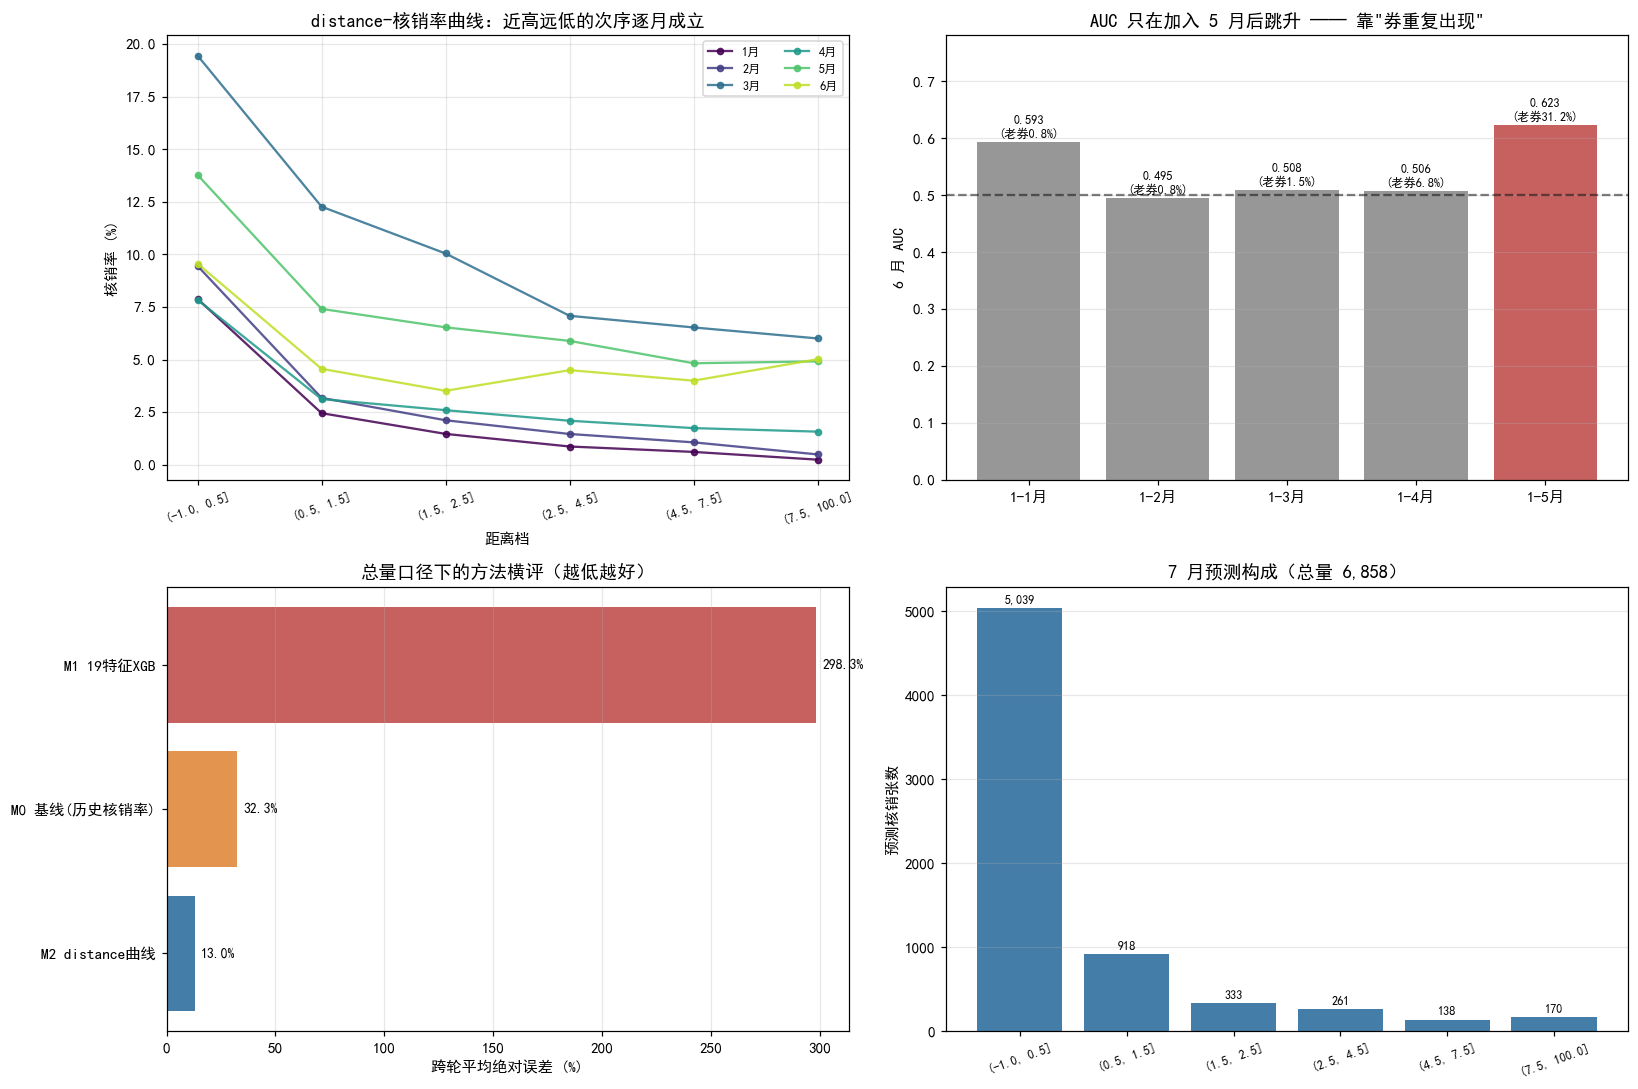

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) 各月 distance-核销率曲线
ax = axes[0, 0]
for m, c in zip(range(1, 7), plt.cm.viridis(np.linspace(0, 0.9, 6))):
    s = df_train[df_train['receive_month'] == m]
    r = s.groupby('dbin', observed=True)['class'].mean() * 100
    ax.plot(range(len(r)), r.values, marker='o', ms=4, label=f'{m}月', color=c, alpha=0.85)
ax.set_xticks(range(len(r)))
ax.set_xticklabels([str(x) for x in r.index], rotation=20, fontsize=8)
ax.set_xlabel('距离档')
ax.set_ylabel('核销率 (%)')
ax.set_title('distance-核销率曲线：近高远低的次序逐月成立', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# (2) AUC 来源诊断
ax = axes[0, 1]
ax.bar(auc_df['训练段'], auc_df['6月AUC'], color=[C_GREY] * 4 + [C_WARN], alpha=0.9)
for i, (v, ov) in enumerate(zip(auc_df['6月AUC'], auc_df['6月行中老券占比%'])):
    ax.annotate(f'{v:.3f}\n(老券{ov}%)', xy=(i, v), xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8)
ax.axhline(0.5, color='k', ls='--', alpha=0.5)
ax.set_ylabel('6 月 AUC')
ax.set_ylim(0, 0.78)
ax.set_title('AUC 只在加入 5 月后跳升 —— 靠"券重复出现"', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (3) 方法横评
ax = axes[1, 0]
gsum = summary.reset_index()
colors = [C_MAIN if 'M2' in n else (C_ALT if 'M0' in n else C_WARN) for n in gsum['方法名']]
bars = ax.barh(gsum['方法名'], gsum['平均绝对误差'], color=colors, alpha=0.9)
for bar, v in zip(bars, gsum['平均绝对误差']):
    ax.annotate(f'{v:.1f}%', xy=(v, bar.get_y() + bar.get_height() / 2), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('跨轮平均绝对误差 (%)')
ax.set_title('总量口径下的方法横评（越低越好）', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# (4) 7 月各档贡献
ax = axes[1, 1]
lbl = [str(x) for x in contrib.index]
ax.bar(lbl, contrib['预测核销'], color=C_MAIN, alpha=0.9, label='预测核销张数')
ax.set_xticklabels(lbl, rotation=20, fontsize=8)
ax.set_ylabel('预测核销张数')
ax.set_title(f'7 月预测构成（总量 {K:,}）', fontweight='bold')
for i, v in enumerate(contrib['预测核销']):
    ax.annotate(f'{v:,.0f}', xy=(i, v), xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / '11_volume_forecast.png', dpi=140)
plt.show()

## 本节小结

| 项 | 结果 |
|---|---|
| **目标** | 不是排序，而是 7 月核销**总量** |
| **关键发现 1** | 19 特征 XGB 在总量口径下误差 **+210%~+368%**，不可用 |
| **关键发现 2** | 09 节的 AUC 0.6227 依赖"券在训练段重复出现"，**不是可迁移能力** |
| **关键发现 3** | `distance` 是唯一跨月稳定（「近高远低」次序不变）的信号，单特征 AUC 约 0.60 |
| **最终方法** | `distance` 单调递减曲线（isotonic） |
| **跨段误差** | 平均绝对值 **约 13%**（基线约 41%，19 特征 XGB 约 298%） |
| **7 月预测总量** | 见 9.1 节 |

### 必须说清楚的限制

1. **月度水平漂移是硬约束**：月度核销率在 2.53%~14.92% 间波动，
   这与模型无关，任何方法都消不掉。跨段误差中最大的一轮（−28%）
   完全由它造成。
2. **7 月的 label 是模型生成的**，没有真值可验证。所有误差数字都来自
   历史模拟，**7 月的实际误差无法事后校验**。
3. **本方法只用了 1 个特征**。这不是"特征工程失败"，而是揭示了一个事实：
   在这份数据上，**能跨月迁移的信息主要就是距离**。其余画像特征的价值
   受限于"券和用户的跨月重合度"，而 7 月有 88.7% 的行是新券。

下一步 → **README 更新**：把本节结论并入十步主线，说明目标从排序切换到总量后的取舍。